In [1]:
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

from recsys.data.loaders import load_movielens
from recsys.utils.colab import get_data_path


In [2]:

DATA_PATH = get_data_path()
ratings, movies = load_movielens("ml-25m", data_dir=DATA_PATH)
ratings.head()

,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510


In [3]:
# Keep ratings/movies loaded from load_movielens in Cell 2
print(ratings.head())
print(f"ratings shape: {ratings.shape}")
print(movies.head())
print(f"movies shape: {movies.shape}")

   userId  movieId  rating   timestamp
0       1      296     5.0  1147880044
1       1      306     3.5  1147868817
2       1      307     5.0  1147868828
3       1      665     5.0  1147878820
4       1      899     3.5  1147868510
ratings shape: (25000095, 4)
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
movies shape: (62423, 3)


In [4]:
from scipy.sparse import csr_matrix

user_ids = ratings['userId'].unique()
movie_ids = ratings['movieId'].unique()
user_to_idx = {uid: idx for idx, uid in enumerate(user_ids)} #A
movie_to_idx = {mid: idx for idx, mid in enumerate(movie_ids)} #A
idx_to_movie = {idx: mid for mid, idx in movie_to_idx.items()} #A

rows = [user_to_idx[uid] for uid in ratings['userId']] #B
cols = [movie_to_idx[mid] for mid in ratings['movieId']] #B
data = [1] * len(ratings) #B

user_item_matrix = csr_matrix(
    (data, (rows, cols)),
    shape=(len(user_ids), len(movie_ids))
) #C
print(f"user_item_matrix shape: {user_item_matrix.shape}")

user_item_matrix shape: (162541, 59047)


In [5]:
movie_counts = ratings['movieId'].value_counts() #A
max_count = movie_counts.max() #B

popularity_scores = {
    int(mid): float(count / max_count)
    for mid, count in movie_counts.items()
}


In [11]:
from sklearn.metrics.pairwise import cosine_similarity

item_similarity = cosine_similarity(user_item_matrix.T, dense_output=False) #A
print(f"Similarity matrix shape: {item_similarity.shape}")
print(f"Similarity matrix memory: {item_similarity.data.nbytes / 1024 / 1024:.1f} MB")


Similarity matrix shape: (59047, 59047)
Similarity matrix memory: 10411.8 MB


In [12]:
def retrieve_similar_items(movie_id, k=100) -> list[dict]: #A
    if movie_id not in movie_to_idx:
        return []
    
    movie_idx = movie_to_idx[movie_id]
    similarities = item_similarity[movie_idx].toarray()[0]
    
    top_indices = np.argsort(similarities)[-(k+1):-1][::-1]
    
    candidates = []
    for idx in top_indices:
        candidates.append({
            'movie_id': idx_to_movie[idx],
            'similarity': float(similarities[idx])
        })
    
    return candidates


In [6]:
seed_movie_id = 1270

seed_title = movies[movies['movieId'] == seed_movie_id]['title'].values[0] #A
candidates = retrieve_similar_items(seed_movie_id, k=10)
print(f"Movies similar to '{seed_title}':\n")
for i, item in enumerate(candidates[:5], 1):
    title = movies[movies['movieId'] == item['movie_id']]['title'].values[0]
    print(f"{i}. {title}, ID: {item['movie_id']}")

    print(f"   Similarity: {item['similarity']:.3f}\n")


NameError: name 'retrieve_similar_items' is not defined

In [172]:
def get_user_history(user_id, k=None) -> int: #A
    user_rows = ratings[ratings["userId"] == user_id]
    user_rows = user_rows.sort_values("timestamp")
    movie_ids = user_rows["movieId"].tolist()
    return set(movie_ids) if k is None else set(movie_ids[-k:])

def filter_watched(candidates, user_id) -> list[dict]: #B
    user_history = get_user_history(user_id)
    
    filtered = [
        item for item in candidates
        if item['movie_id'] not in user_history
    ]    
    return filtered



{296,
 306,
 307,
 665,
 899,
 1088,
 1175,
 1217,
 1237,
 1250,
 1260,
 1653,
 2011,
 2012,
 2068,
 2161,
 2351,
 2573,
 2632,
 2692,
 2843,
 3448,
 3569,
 3949,
 4144,
 4308,
 4325,
 4422,
 4703,
 4973,
 5147,
 5269,
 5684,
 5767,
 5878,
 5912,
 5952,
 6016,
 6370,
 6377,
 6539,
 6711,
 6954,
 7209,
 7234,
 7318,
 7323,
 7327,
 7361,
 7365,
 7820,
 7937,
 7938,
 7939,
 7940,
 8014,
 8154,
 8327,
 8360,
 8405,
 8685,
 8729,
 8786,
 8873,
 8973,
 27193,
 27266,
 27721,
 31956,
 32591}

In [187]:
test_user = 1
user_history = get_user_history(test_user)

print(f"User {test_user} has watched {len(user_history)} movies")

candidates = retrieve_similar_items(seed_movie_id, k=100)

print(f"Candidates before filtering: {len(candidates)}")
filtered = filter_watched(candidates, test_user)

print(f"Candidates after filtering: {len(filtered)}")



User 1 has watched 70 movies
Candidates before filtering: 100
Candidates after filtering: 94


In [188]:
def score_popularity(candidates):
    for item in candidates:
        item['popularity'] = popularity_scores.get(item['movie_id'], 0.0)
    return candidates

candidates = retrieve_similar_items(seed_movie_id, k=10)
candidates = filter_watched(candidates, test_user)
candidates = score_popularity(candidates)

print(f"Candidates with multiple scores:\n")
for item in candidates[:3]:
    title = movies[movies['movieId'] == item['movie_id']]['title'].values[0]
    print(f"{title}")
    print(f"  Similarity: {item['similarity']:.3f}")
    print(f"  Popularity: {item['popularity']:.3f}\n")


Candidates with multiple scores:

Star Wars: Episode V - The Empire Strikes Back (1980)
  Similarity: 0.648
  Popularity: 0.704

Terminator, The (1984)
  Similarity: 0.638
  Popularity: 0.474

Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)
  Similarity: 0.629
  Popularity: 0.671



In [189]:
def rank_candidates(candidates, similarity_weight=0.7, k=10):
    for item in candidates:
        item['final_score'] = (
            similarity_weight * item['similarity'] +
            (1 - similarity_weight) * item['popularity']
        ) #A
    
    ranked = sorted(
        candidates,
        key=lambda x: x['final_score'],
        reverse=True
    ) #B
    
    return ranked[:k] #C


In [190]:
candidates = retrieve_similar_items(seed_movie_id, k=10)
candidates = filter_watched(candidates, test_user)
candidates = score_popularity(candidates)

weighted_results = []
for weight in [1.0, 0.5, 0.0]:
    ranked = rank_candidates(candidates, similarity_weight=weight, k=5)
    weighted_results.append((weight, ranked))
    print(f"\nWeight={weight:.1f} (similarity={weight:.0%}, popularity={1-weight:.0%}):")
    for i, item in enumerate(ranked, 1):
        title = movies[movies['movieId'] == item['movie_id']]['title'].values[0]
        print(f"  {i}. {title[:45]}")



Weight=1.0 (similarity=100%, popularity=0%):
  1. Star Wars: Episode V - The Empire Strikes Bac
  2. Terminator, The (1984)
  3. Raiders of the Lost Ark (Indiana Jones and th
  4. Star Wars: Episode VI - Return of the Jedi (1
  5. E.T. the Extra-Terrestrial (1982)

Weight=0.5 (similarity=50%, popularity=50%):
  1. Matrix, The (1999)
  2. Star Wars: Episode IV - A New Hope (1977)
  3. Star Wars: Episode V - The Empire Strikes Bac
  4. Star Wars: Episode VI - Return of the Jedi (1
  5. Raiders of the Lost Ark (Indiana Jones and th

Weight=0.0 (similarity=0%, popularity=100%):
  1. Matrix, The (1999)
  2. Star Wars: Episode IV - A New Hope (1977)
  3. Star Wars: Episode V - The Empire Strikes Bac
  4. Star Wars: Episode VI - Return of the Jedi (1
  5. Raiders of the Lost Ark (Indiana Jones and th


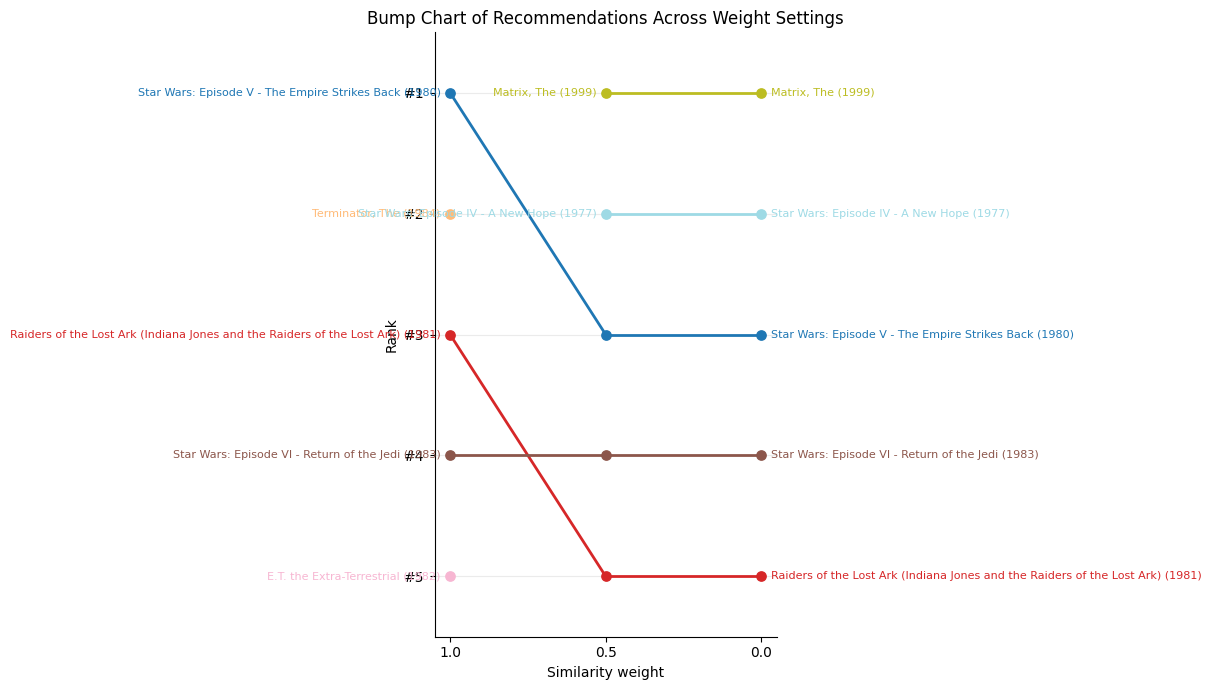

In [191]:
# Build bump-chart data from weighted_results
weights = [w for w, _ in weighted_results]
max_rank = max(len(ranked) for _, ranked in weighted_results)

rankings = {}
for col_idx, (_, ranked_list) in enumerate(weighted_results):
    for rank, rec in enumerate(ranked_list, start=1):
        movie_id = int(rec["movie_id"])
        title = movies.loc[movies["movieId"] == movie_id, "title"].iloc[0]

        if title not in rankings:
            rankings[title] = [None] * len(weights)
        rankings[title][col_idx] = rank

# Plot bump chart
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(weights))
palette = plt.cm.tab20(np.linspace(0, 1, max(len(rankings), 1)))

for color, (title, ranks) in zip(palette, rankings.items()):
    # Draw connected segments only where both endpoints exist
    for i in range(len(ranks) - 1):
        if ranks[i] is not None and ranks[i + 1] is not None:
            ax.plot([x[i], x[i + 1]], [ranks[i], ranks[i + 1]], color=color, linewidth=2)

    # Draw points
    for i, r in enumerate(ranks):
        if r is not None:
            ax.scatter(x[i], r, color=color, s=45, zorder=3)

    # Label at first and last available positions
    first_idx = next((i for i, r in enumerate(ranks) if r is not None), None)
    last_idx = next((i for i in range(len(ranks) - 1, -1, -1) if ranks[i] is not None), None)

    if first_idx is not None:
        ax.text(x[first_idx] - 0.06, ranks[first_idx], title, ha="right", va="center", fontsize=8, color=color)
    if last_idx is not None and last_idx != first_idx:
        ax.text(x[last_idx] + 0.06, ranks[last_idx], title, ha="left", va="center", fontsize=8, color=color)

ax.set_xticks(x)
ax.set_xticklabels([f"{w:.1f}" for w in weights])
ax.set_yticks(range(1, max_rank + 1))
ax.set_yticklabels([f"#{i}" for i in range(1, max_rank + 1)])
ax.set_ylim(max_rank + 0.5, 0.5)  # rank 1 at top
ax.set_xlabel("Similarity weight")
ax.set_ylabel("Rank")
ax.set_title("Bump Chart of Recommendations Across Weight Settings")
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [192]:
def recommend_for_user(user_id, k=10, similarity_weight=0.7):
    user_history = get_user_history(user_id)
    
    if len(user_history) == 0:
        popular_movies = movie_counts.head(k).index.tolist()
        return [{'movie_id': int(mid)} for mid in popular_movies]
    
    all_candidates = {}
    recent_movies = list(user_history)[-10:]
    
    for movie_id in recent_movies:
        candidates = retrieve_similar_items(movie_id, k=50)
        
        for item in candidates:
            mid = item['movie_id']
            score = item['similarity']
            
            if mid in all_candidates:
                all_candidates[mid] = max(all_candidates[mid], score)
            else:
                all_candidates[mid] = score
    
    candidates = [
        {'movie_id': mid, 'similarity': score}
        for mid, score in all_candidates.items()
    ]
    
    candidates = score_popularity(candidates)
    
    candidates = filter_watched(candidates, user_id)
    
    ranked = rank_candidates(candidates, similarity_weight, k)
    
    return ranked


In [193]:
def print_user_watch_history(user_id, k=10):
    watched = list(get_user_history(user_id))[-k:]
    titles = [movies[movies['movieId'] == movie_id]['title'].values[0] for movie_id in watched]        
    print(f"Watched: {', '.join(titles)}")
print_user_watch_history(1)
def print_recs(recommendations):
    for i, item in enumerate(recommendations, 1):
        title = movies[movies['movieId'] == item['movie_id']]['title'].values[0]
        sim = item['similarity']
        pop = item['popularity']
        final = item['final_score']
        
        print(f"{i:2d}. {title}\t  Final: {final:.3f} (sim: {sim:.3f}, pop: {pop:.3f})")


Watched: Finding Nemo (2003), M (1931), Requiem for a Dream (2000), Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001), Miracle of Marcelino, The (Marcelino pan y vino) (1955), NeverEnding Story, The (1984), Idiots, The (Idioterne) (1998), Gattaca (1997), Talk to Her (Hable con Ella) (2002), Good Morning, Vietnam (1987)


In [194]:
user_id = 1

recommendations = recommend_for_user(user_id, k=5, similarity_weight=0.7)

print(f"Top 5 recommendations for User {user_id}:\n")
print_user_watch_history(user_id, k=5)

print_recs(recommendations)

Top 5 recommendations for User 1:

Watched: NeverEnding Story, The (1984), Idiots, The (Idioterne) (1998), Gattaca (1997), Talk to Her (Hable con Ella) (2002), Good Morning, Vietnam (1987)
 1. Matrix, The (1999)	  Final: 0.641 (sim: 0.534, pop: 0.892)
 2. Forrest Gump (1994)	  Final: 0.636 (sim: 0.479, pop: 1.000)
 3. Shrek (2001)	  Final: 0.629 (sim: 0.676, pop: 0.519)
 4. Lord of the Rings: The Fellowship of the Ring, The (2001)	  Final: 0.627 (sim: 0.602, pop: 0.684)
 5. Monsters, Inc. (2001)	  Final: 0.626 (sim: 0.712, pop: 0.424)


In [208]:
def get_most_popular_movies(k=10):
    top_k_ids = sorted(popularity_scores, key=popularity_scores.get, reverse=True)[:k]
    # top_k = [{"movie_id": movies[movies['movieId'] == mid]['title'].values[0],
    #           "popularity_score": popularity_scores[mid]} for mid in top_k_ids]

    return top_k_ids
get_most_popular_movies(10 )

[356, 318, 296, 593, 2571, 260, 480, 527, 110, 2959]

In [209]:

def recommend_for_user(user_id, k=10, similarity_weight=0.7):
    user_history = get_user_history(user_id)
    
    # Get popular movies as the candidate pool
    popular_movie_ids = get_most_popular_movies(k=k*3)
    
    # Build candidates from popular movies with default similarity of 0
    all_candidates = {mid: 0.0 for mid in popular_movie_ids}
    
    # Re-score candidates using similarity to user's recent watch history
    recent_movies = list(user_history)[-10:]
    for movie_id in recent_movies:
        similar_items = retrieve_similar_items(movie_id, k=50)
        for item in similar_items:
            mid = item['movie_id']
            if mid in all_candidates:  # only update if it's already a popular candidate
                all_candidates[mid] = max(all_candidates[mid], item['similarity'])
    
    candidates = [
        {'movie_id': mid, 'similarity': score}
        for mid, score in all_candidates.items()
    ]
    
    candidates = score_popularity(candidates)
    candidates = filter_watched(candidates, user_id)
    ranked = rank_candidates(candidates, similarity_weight, k)
    
    return ranked

In [210]:
recommendations = recommend_for_user(5, k=5, similarity_weight=0.7)
print_user_watch_history(1, k=5)
for i, item in enumerate(recommendations, 1):
    title = movies[movies['movieId'] == item['movie_id']]['title'].values[0]
    sim = item['similarity']
    pop = item['popularity']
    final = item['final_score']
    
    print(f"{i:2d}. {title}\t  Final: {final:.3f} (sim: {sim:.3f}, pop: {pop:.3f})")


Watched: NeverEnding Story, The (1984), Idiots, The (Idioterne) (1998), Gattaca (1997), Talk to Her (Hable con Ella) (2002), Good Morning, Vietnam (1987)
 1. Jurassic Park (1993)	  Final: 0.695 (sim: 0.655, pop: 0.787)
 2. Shawshank Redemption, The (1994)	  Final: 0.683 (sim: 0.547, pop: 1.000)
 3. Terminator 2: Judgment Day (1991)	  Final: 0.661 (sim: 0.642, pop: 0.704)
 4. Braveheart (1995)	  Final: 0.648 (sim: 0.614, pop: 0.726)
 5. Schindler's List (1993)	  Final: 0.574 (sim: 0.503, pop: 0.741)


## Popular for you

In [211]:
def score_candidates_vs_seeds(candidate_movie_ids, seed_movie_ids, agg="max"):
    candidate_movie_ids = list(candidate_movie_ids)  #A
    seed_movie_ids = list(seed_movie_ids)  #A

    score_map = {mid: 0.0 for mid in candidate_movie_ids}  #B

    valid_candidate_ids = [mid for mid in candidate_movie_ids if mid in movie_to_idx]  #C
    valid_seed_ids = [mid for mid in seed_movie_ids if mid in movie_to_idx]  #C

    if not valid_candidate_ids or not valid_seed_ids:  #D
        return score_map

    candidate_indices = [movie_to_idx[mid] for mid in valid_candidate_ids]  #E
    seed_indices = [movie_to_idx[mid] for mid in valid_seed_ids]  #E

    sim_block = item_similarity[candidate_indices][:, seed_indices]  #F

    if agg == "mean":  #G
        vals = np.asarray(sim_block.mean(axis=1)).ravel()
    else:
        max_vals = sim_block.max(axis=1)
        vals = max_vals.toarray().ravel() if hasattr(max_vals, "toarray") else np.asarray(max_vals).ravel()

    score_map.update(dict(zip(valid_candidate_ids, vals)))  #H
    return score_map  #I


def reorder_candidates_by_seed_similarity(candidate_movie_ids, seed_movie_ids, agg="max"):
    candidate_movie_ids = list(candidate_movie_ids)  #J
    score_map = score_candidates_vs_seeds(candidate_movie_ids, seed_movie_ids, agg=agg)  #K

    result = pd.DataFrame({"movieId": candidate_movie_ids})  #L
    result["seed_similarity"] = result["movieId"].map(score_map).fillna(0.0)

    meta_cols = [c for c in ["movieId", "title", "genres"] if c in movies.columns]
    result = result.merge(movies[meta_cols].drop_duplicates("movieId"), on="movieId", how="left")  #M

    result = result.sort_values(["seed_similarity", "movieId"], ascending=[False, True], kind="mergesort")  #N
    return result


In [218]:
user_id = 1
candidates = get_most_popular_movies(k=10)
user_movie_ids = list(get_user_history(user_id, k=5))
candidates = [candidate for candidate in candidates if candidate not in user_movie_ids]  # Filter out watched movies from candidates
print(f"User {user_id} history: {[movies[movies['movieId'] == mid]['title'].values[0] for mid in user_movie_ids]}")
recs = reorder_candidates_by_seed_similarity(candidates, user_movie_ids)

for _, row in recs.iterrows():
    title = row['title']
    score = row['seed_similarity']
    print(f"{title}: {score:.3f}")

[356, 318, 296, 593, 2571, 260, 480, 527, 110, 2959]
User 1 history: ['Eternal Sunshine of the Spotless Mind (2004)', 'Pulp Fiction (1994)', 'Naqoyqatsi (2002)', 'Passion of the Christ, The (2004)', 'Taxi 2 (2000)']
Silence of the Lambs, The (1991): 0.718
Shawshank Redemption, The (1994): 0.694
Forrest Gump (1994): 0.682
Jurassic Park (1993): 0.621
Braveheart (1995): 0.616
Fight Club (1999): 0.609
Schindler's List (1993): 0.600
Matrix, The (1999): 0.597
Star Wars: Episode IV - A New Hope (1977): 0.556


In [220]:
pop_movies = get_most_popular_movies(10)
print("Most popular movies:")
for mid in pop_movies:
    title = movies[movies['movieId'] == mid]['title'].values[0]
    score = popularity_scores.get(mid, 0.0)
    print(f"{title}: {score:.3f}")

Most popular movies:
Forrest Gump (1994): 1.000
Shawshank Redemption, The (1994): 1.000
Pulp Fiction (1994): 0.978
Silence of the Lambs, The (1991): 0.910
Matrix, The (1999): 0.892
Star Wars: Episode IV - A New Hope (1977): 0.843
Jurassic Park (1993): 0.787
Schindler's List (1993): 0.741
Braveheart (1995): 0.726
Fight Club (1999): 0.721


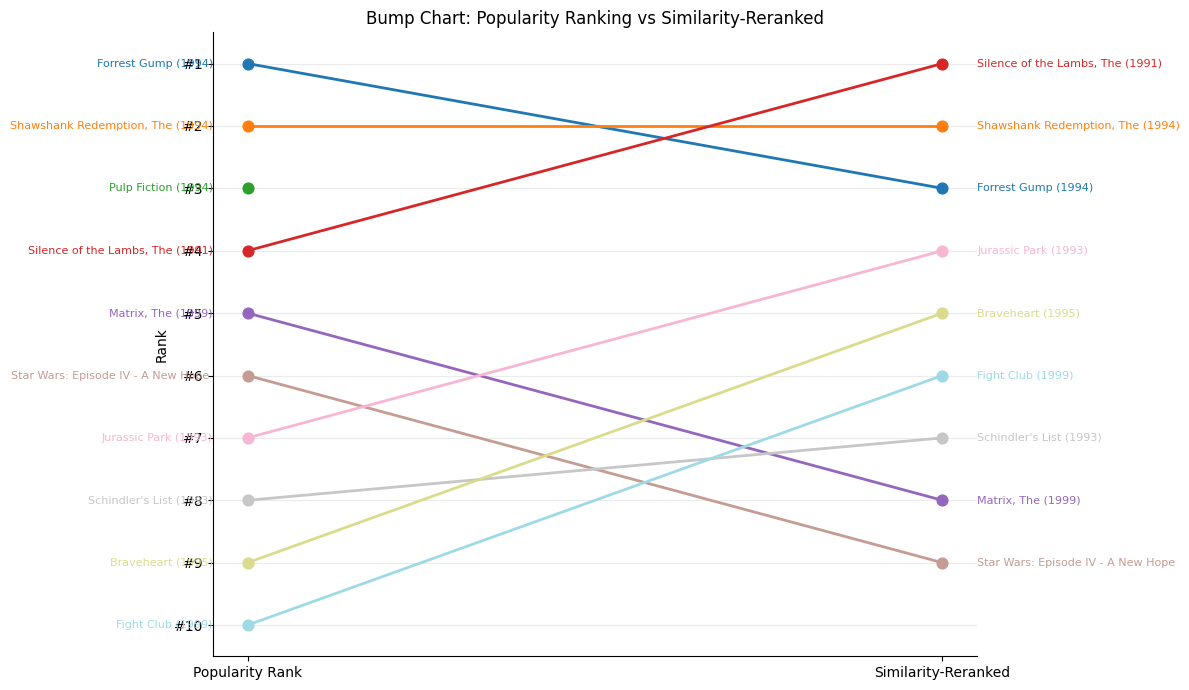

In [221]:
# Build bump-chart data comparing pop_movies vs recs rankings

# pop_movies: list of movie_ids ranked by popularity
# recs: DataFrame with columns ['movieId', 'seed_similarity', 'title', 'genres']

pop_titles = [movies[movies['movieId'] == mid]['title'].values[0] for mid in pop_movies]
rec_titles = recs['title'].tolist()

all_titles = list(dict.fromkeys(pop_titles + rec_titles))  # unique, preserving order

bump_data = {}
for title in all_titles:
    pop_rank = pop_titles.index(title) + 1 if title in pop_titles else None
    rec_rank = rec_titles.index(title) + 1 if title in rec_titles else None
    bump_data[title] = [pop_rank, rec_rank]

# Plot bump chart
fig, ax = plt.subplots(figsize=(12, 7))
x = np.array([0, 1])
x_labels = ["Popularity Rank", "Similarity-Reranked"]
palette = plt.cm.tab20(np.linspace(0, 1, len(bump_data)))

for color, (title, ranks) in zip(palette, bump_data.items()):
    if ranks[0] is not None and ranks[1] is not None:
        ax.plot(x, ranks, color=color, linewidth=2)
    for i, r in enumerate(ranks):
        if r is not None:
            ax.scatter(x[i], r, color=color, s=60, zorder=3)

    first_idx = next((i for i, r in enumerate(ranks) if r is not None), None)
    last_idx = next((i for i in range(len(ranks)-1, -1, -1) if ranks[i] is not None), None)

    if first_idx is not None:
        ax.text(x[first_idx] - 0.05, ranks[first_idx], title[:35], ha="right", va="center", fontsize=8, color=color)
    if last_idx is not None and last_idx != first_idx:
        ax.text(x[last_idx] + 0.05, ranks[last_idx], title[:35], ha="left", va="center", fontsize=8, color=color)

max_rank = max(r for ranks in bump_data.values() for r in ranks if r is not None)
ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_yticks(range(1, max_rank + 1))
ax.set_yticklabels([f"#{i}" for i in range(1, max_rank + 1)])
ax.set_ylim(max_rank + 0.5, 0.5)
ax.set_ylabel("Rank")
ax.set_title("Bump Chart: Popularity Ranking vs Similarity-Reranked")
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

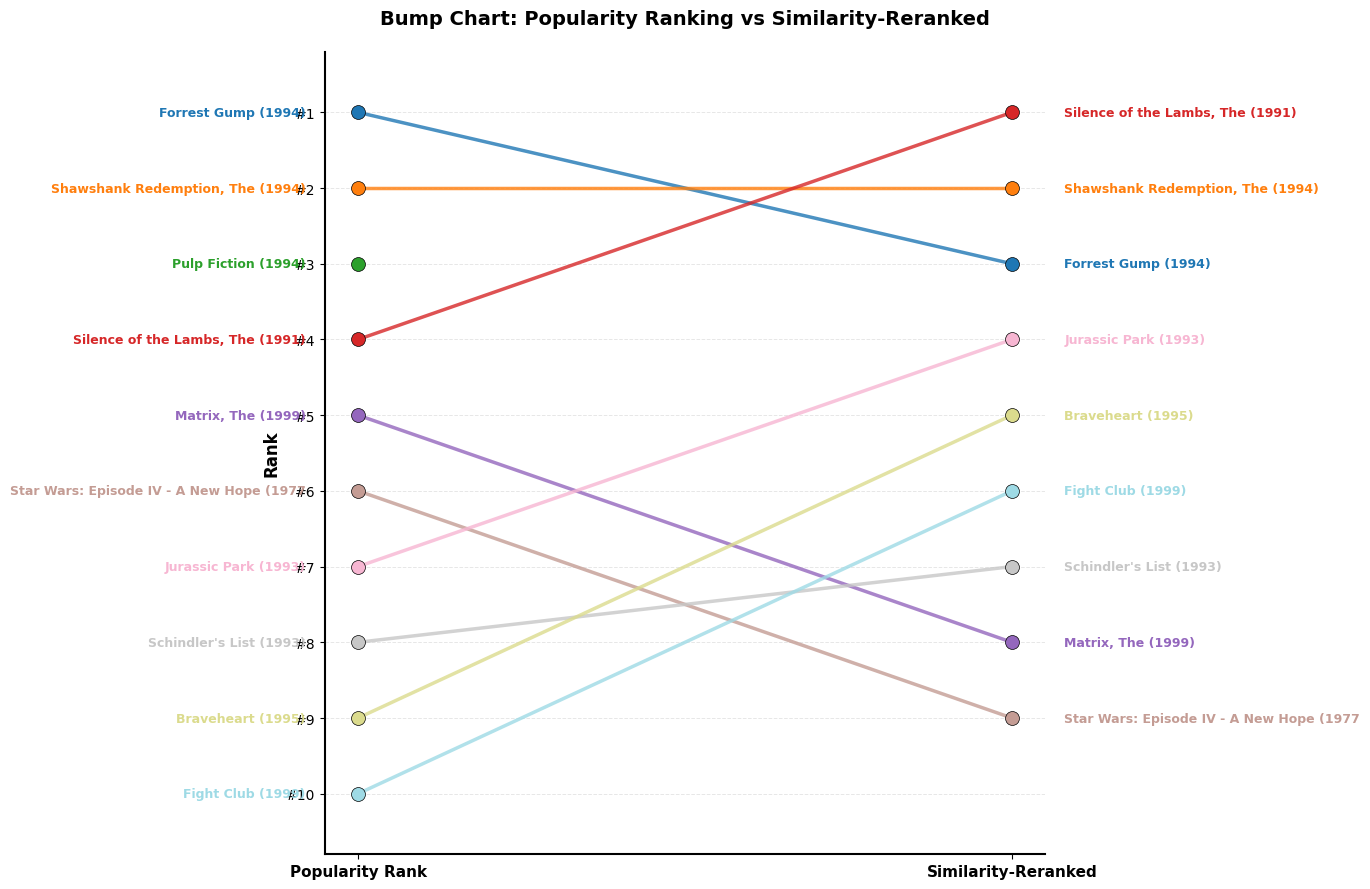

In [222]:
pop_titles = [movies[movies['movieId'] == mid]['title'].values[0] for mid in pop_movies]  #A
rec_titles = recs['title'].tolist()  #A

all_titles = list(dict.fromkeys(pop_titles + rec_titles))  #B

bump_data = {}  #C
for title in all_titles:
    pop_rank = pop_titles.index(title) + 1 if title in pop_titles else None  #D
    rec_rank = rec_titles.index(title) + 1 if title in rec_titles else None  #D
    bump_data[title] = [pop_rank, rec_rank]

fig, ax = plt.subplots(figsize=(14, 9))  #E
x = np.array([0, 1])  #F
x_labels = ["Popularity Rank", "Similarity-Reranked"]  #F
palette = plt.cm.tab20(np.linspace(0, 1, len(bump_data)))  #G

for color, (title, ranks) in zip(palette, bump_data.items()):  #H
    if ranks[0] is not None and ranks[1] is not None:  #I
        ax.plot(x, ranks, color=color, linewidth=2.5, alpha=0.8)
    
    for i, r in enumerate(ranks):  #J
        if r is not None:
            ax.scatter(x[i], r, color=color, s=100, zorder=3, edgecolors='black', linewidth=0.5)

    first_idx = next((i for i, r in enumerate(ranks) if r is not None), None)  #K
    last_idx = next((i for i in range(len(ranks)-1, -1, -1) if ranks[i] is not None), None)

    if first_idx is not None:  #L
        ax.text(x[first_idx] - 0.08, ranks[first_idx], title[:40], ha="right", va="center", 
                fontsize=9, color=color, weight='bold')
    if last_idx is not None and last_idx != first_idx:
        ax.text(x[last_idx] + 0.08, ranks[last_idx], title[:40], ha="left", va="center", 
                fontsize=9, color=color, weight='bold')

max_rank = max(r for ranks in bump_data.values() for r in ranks if r is not None)  #M
ax.set_xticks(x)  #N
ax.set_xticklabels(x_labels, fontsize=11, weight='bold')
ax.set_yticks(range(1, max_rank + 1))
ax.set_yticklabels([f"#{i}" for i in range(1, max_rank + 1)], fontsize=10)
ax.set_ylim(max_rank + 0.8, 0.2)
ax.set_ylabel("Rank", fontsize=12, weight='bold')
ax.set_title("Bump Chart: Popularity Ranking vs Similarity-Reranked", fontsize=14, weight='bold', pad=20)
ax.grid(axis="y", alpha=0.3, linestyle='--', linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_linewidth(1.5)

plt.tight_layout()
plt.show()

In [225]:
new_movie_id = 209157
new_movie = movies[movies['movieId'] == new_movie_id]

print(f"New movie: {new_movie['title'].values[0]}")
print(f"Genres: {new_movie['genres'].values[0]}")

num_ratings = len(ratings[ratings['movieId'] == new_movie_id])
print(f"Number of ratings: {num_ratings}")

candidates = retrieve_similar_items(new_movie_id, k=10)
print(f"Similar items found: {len(candidates)}")


New movie: We (2018)
Genres: Drama
Number of ratings: 1
Similar items found: 10
